# Financial RAG

Retrieval-Augmented Generation combines document retrieval with answer generation. This notebook builds an offline financial RAG prototype using simple TF-IDF retrieval.

Abbreviations used in this notebook:

- **RAG**: Retrieval-Augmented Generation.
- **TF-IDF**: Term Frequency-Inverse Document Frequency.
- **TF**: Term Frequency, how often a term appears in a document.
- **IDF**: Inverse Document Frequency, how rare a term is across documents.
- **DCF**: Discounted Cash Flow.
- **FCF**: Free Cash Flow.
- **WACC**: Weighted Average Cost of Capital.
- **LLM**: Large Language Model.

## 1. Intuition

A financial RAG system answers questions by first finding relevant source material, then using those sources to support a response. The retrieval step is crucial because it controls what evidence the system sees.

In production, an LLM would synthesize the final answer. Here we keep everything deterministic and offline so the mechanics are visible.

## 2. Mathematics

TF-IDF weight:

$$
Weight_{term,doc} = TF_{term,doc} \times IDF_{term}
$$

Cosine similarity:

$$
Similarity(q,d) = \frac{q \cdot d}{||q||\ ||d||}
$$

RAG flow:

$$
Question \rightarrow Retrieval \rightarrow Context \rightarrow Answer
$$

## 3. Implementation

We create a synthetic document set, retrieve relevant documents for a question, and produce a grounded answer template.

In [1]:
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "GUIDELINES.md").exists())
helper_path = project_root / "06_ai_agents" / "ai_utils.py"
spec = importlib.util.spec_from_file_location("ai_utils", helper_path)
ai_utils = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ai_utils)

plt.style.use("seaborn-v0_8-whitegrid")
documents = ai_utils.sample_financial_documents()

documents

,doc_id,ticker,source,section,date,text
0,nestle_annual_2024,NESN.SW,annual_report,cash_flow,2024-12-31,Nestle generated resilient free cash flow supp...
1,nestle_annual_2024_margin,NESN.SW,annual_report,profitability,2024-12-31,Gross margin improved as input cost pressure e...
2,nestle_risk_2024,NESN.SW,risk_factors,risk,2024-12-31,"Key risks include commodity inflation, foreign..."
3,peer_note_2024,PEER.FOOD,analyst_note,valuation,2024-11-15,Consumer staples peers trade at premium multip...
4,market_data_2024,NESN.SW,market_data,price,2024-12-31,The share price declined modestly while volati...
5,valuation_model_base,NESN.SW,model,dcf,2025-01-10,The base DCF assumes 3.5 percent revenue growt...


In [2]:
question = "Is Nestle free cash flow resilient and what risks matter for valuation?"
retrieved = ai_utils.retrieve(documents, question, top_k=4, ticker="NESN.SW")
retrieved[["doc_id", "source", "section", "score", "text"]]

,doc_id,source,section,score,text
0,nestle_annual_2024,annual_report,cash_flow,0.462723,Nestle generated resilient free cash flow supp...
5,valuation_model_base,model,dcf,0.207384,The base DCF assumes 3.5 percent revenue growt...
2,nestle_risk_2024,risk_factors,risk,0.164087,"Key risks include commodity inflation, foreign..."
1,nestle_annual_2024_margin,annual_report,profitability,0.051838,Gross margin improved as input cost pressure e...


In [3]:
def grounded_answer(question, retrieved_documents):
    bullets = []
    for row in retrieved_documents.itertuples(index=False):
        bullets.append(f"- {row.section}: {row.text}")
    return "Question: " + question + "\n\nRetrieved evidence:\n" + "\n".join(bullets)

print(grounded_answer(question, retrieved))

Question: Is Nestle free cash flow resilient and what risks matter for valuation?

Retrieved evidence:
- cash_flow: Nestle generated resilient free cash flow supported by pricing power, disciplined capital expenditure, and stable working capital.
- dcf: The base DCF assumes 3.5 percent revenue growth, 13.5 percent free cash flow margin, 6.0 percent WACC, and 2.0 percent terminal growth.
- risk: Key risks include commodity inflation, foreign exchange volatility, changing consumer preferences, and regulatory scrutiny.
- profitability: Gross margin improved as input cost pressure eased. Operating margin remained supported by premium brands and productivity programs.


## 4. Visualization

Retrieval scores help diagnose whether the system found useful evidence or weakly related text.

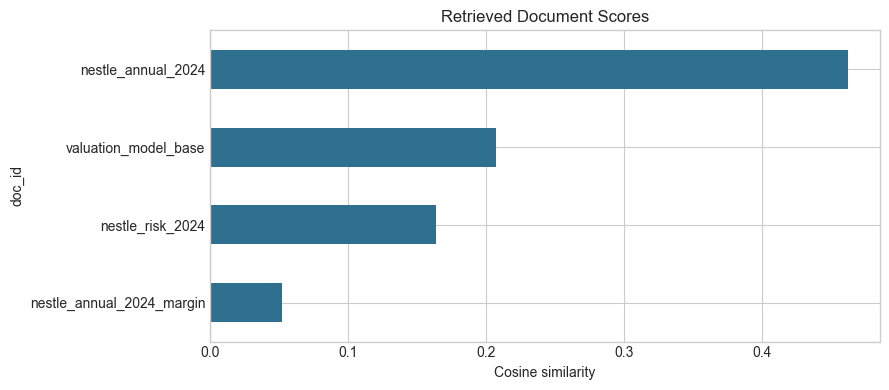

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
retrieved.sort_values("score").plot(x="doc_id", y="score", kind="barh", ax=ax, color="#2f6f8f", legend=False)
ax.set_title("Retrieved Document Scores")
ax.set_xlabel("Cosine similarity")
plt.tight_layout(); plt.show()

## 5. Application

Financial RAG can support analyst workflows: retrieving financial statement notes, risk factors, valuation assumptions, market data explanations, and prior investment theses.

The important rule is traceability. Every generated claim should be linked back to retrieved evidence.

In [5]:
coverage = retrieved.groupby(["source", "section"]).size().to_frame("retrieved_count")
coverage

retrieved_count
source        section                       
annual_report cash_flow                    1
              profitability                1
model         dcf                          1
risk_factors  risk                         1

## 6. Reflection

- RAG quality depends on retrieval quality.
- Metadata filters reduce irrelevant context.
- Source traceability matters in financial analysis.
- Offline prototypes are useful before connecting an LLM or vector database.

Questions to answer after running the notebook:

1. Which document was most relevant?
2. Did retrieval cover both cash flow and risk?
3. What metadata would improve retrieval?
4. What could go wrong if retrieval misses an important risk?